# Полносвязные сети, свёртки и CNN
### Курс: Машинное обучение / Компьютерное зрение

## О чём этот ноутбук

Прежде чем перейти к CNN, важно понять, почему обычные полносвязные сети плохо справляются с изображениями. Мы пройдём путь:

- Полносвязная сеть как baseline: обучаем, считаем параметры, находим слабые места
- Операция свёртки: реализуем с нуля, разбираем механику
- Классические ядра свёртки: что они "видят"
- Padding, Stride, Pooling: управление размером и инвариантностью
- CNN-классификатор на PyTorch: строим, обучаем, сравниваем с полносвязной сетью
- Визуализация: что происходит внутри обученной CNN

## Структура занятия

| Раздел | Тема |
|--------|------|
| 0 | Установка и импорты |
| 1 | Полносвязные сети vs CNN: в чём проблема |
| 2 | Изображение как тензор |
| 3 | Полносвязная сеть: baseline-реализация и обучение |
| 4 | Операция свёртки с нуля |
| 5 | Классические ядра свёртки |
| 6 | Padding, Stride, Pooling |
| 7 | CNN-классификатор на PyTorch |
| 8 | Обучение и прямое сравнение CNN vs FC |
| 9 | Визуализация feature maps и выученных фильтров |
| 10 | Итоговая панель |


---

## Раздел 0: Установка и импорты

Убедитесь, что включён GPU: **Runtime -> Change runtime type -> T4 GPU**.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import torchvision
import torchvision.transforms as transforms

from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Память: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

torch.manual_seed(42)
np.random.seed(42)

Устройство: cuda
GPU: Tesla T4
Память: 15.6 GB


---

## Раздел 1: Полносвязные сети vs CNN — в чём проблема

### Полносвязный слой (Linear / Dense)

Каждый нейрон связан со **всеми** входами. Для изображения это означает, что слой "разворачивает" картинку в один длинный вектор и теряет всякое понятие о том, что пиксели расположены рядом друг с другом.

### Три фундаментальные проблемы Linear-слоёв для изображений

**1. Взрывной рост параметров**

Для изображения 224x224x3 (стандартный размер в CV) количество входов: `224*224*3 = 150,528`. Полносвязный слой со скромными 1000 нейронами даёт **150 миллионов** параметров — это уже больше, чем во многих полноценных CNN-архитектурах суммарно.

**2. Нет учёта пространственной структуры**

Linear-слой не "знает", что пиксель `(10,10)` находится рядом с `(10,11)`. Если переставить все пиксели изображения в случайном, но фиксированном порядке (и сделать это последовательно для всех примеров), Linear-сеть выдаст **тот же результат** — для неё это просто вектор чисел. Для CNN такая перестановка полностью разрушит работу сети, потому что она явно использует соседство пикселей.

**3. Нет translation invariance (инвариантности к сдвигу)**

Если объект на изображении сдвинуть на несколько пикселей, Linear-сеть видит **совершенно другой** входной вектор и должна заново "выучить" этот случай. CNN благодаря shared weights (один и тот же фильтр применяется по всему изображению) распознаёт объект независимо от его положения.

### Решение: свёртка (Convolution)

Свёрточный слой использует:
- **Local connectivity**: каждый нейрон смотрит только на маленькую локальную область (рецептивное поле)
- **Parameter sharing**: один и тот же набор весов (фильтр) применяется по всему изображению — резко снижает число параметров
- **Translation equivariance**: сдвиг объекта на входе сдвигает его признаки в feature map точно так же

Мы это всё продемонстрируем на практике в следующих разделах.

---

## Раздел 2: Изображение как тензор

Для нейросети изображение — это тензор чисел. `(C, H, W)` в PyTorch (channels-first): число каналов, высота, ширина. Grayscale — 1 канал, RGB — 3.

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 483kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.34MB/s]


Форма тензора одного изображения: torch.Size([1, 28, 28])  (C, H, W)
Диапазон значений: [0.000, 1.000]
Train: 60,000  |  Test: 10,000


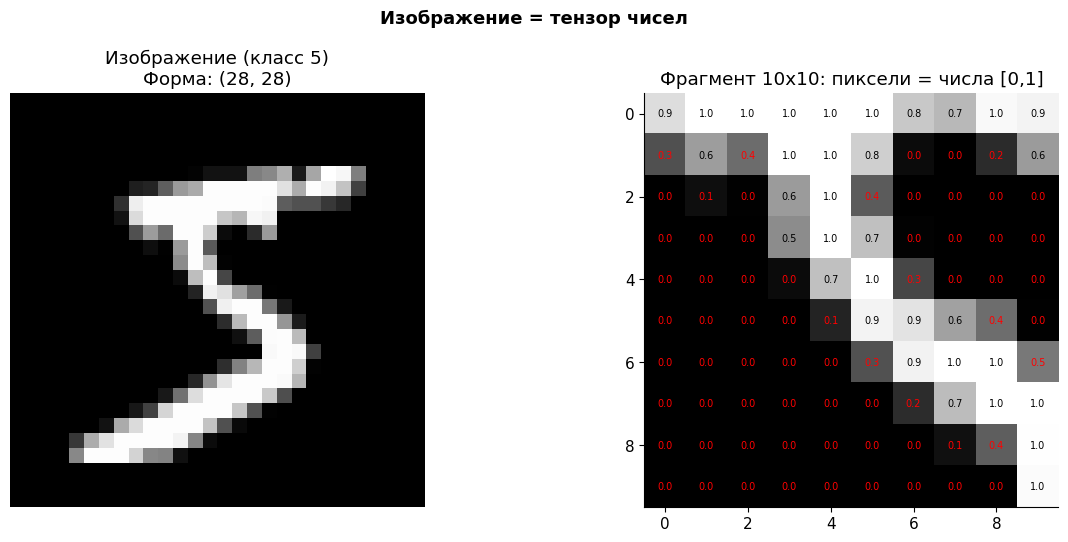

In [3]:
# =============================================================
# Загрузка данных
# =============================================================

transform = transforms.Compose([transforms.ToTensor()])
train_dataset = torchvision.datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

img, label = train_dataset[0]
print(f'Форма тензора одного изображения: {img.shape}  (C, H, W)')
print(f'Диапазон значений: [{img.min():.3f}, {img.max():.3f}]')
print(f'Train: {len(train_dataset):,}  |  Test: {len(test_dataset):,}')

img_np = img.squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].imshow(img_np, cmap='gray')
axes[0].set_title(f'Изображение (класс {label})\nФорма: {img_np.shape}')
axes[0].axis('off')

crop = img_np[8:18, 8:18]
axes[1].imshow(crop, cmap='gray')
for i in range(crop.shape[0]):
    for j in range(crop.shape[1]):
        val = crop[i, j]
        color = 'red' if val < 0.5 else 'black'
        axes[1].text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=7, color=color)
axes[1].set_title('Фрагмент 10x10: пиксели = числа [0,1]')

plt.suptitle('Изображение = тензор чисел', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Раздел 3: Полносвязная сеть — baseline

Построим простую полносвязную сеть (MLP) для классификации MNIST. Она будет нашим baseline для сравнения с CNN на всех уровнях: число параметров, точность, устойчивость к сдвигу.

In [4]:
# =============================================================
# Полносвязная сеть (MLP)
# =============================================================

class FullyConnectedNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),                  # 1x28x28 -> 784
            nn.Linear(784, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.net(x)


fc_model = FullyConnectedNet(num_classes=10).to(device)
n_params_fc = sum(p.numel() for p in fc_model.parameters())
print('Архитектура полносвязной сети:')
print(fc_model)
print(f'\nВсего параметров: {n_params_fc:,}')

# Разбивка по слоям, чтобы увидеть, где "взрываются" параметры
print('\nПараметры по слоям:')
for name, p in fc_model.named_parameters():
    print(f'  {name:20s} {tuple(p.shape)}  ->  {p.numel():,} параметров')

Архитектура полносвязной сети:
FullyConnectedNet(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=10, bias=True)
  )
)

Всего параметров: 535,818

Параметры по слоям:
  net.1.weight         (512, 784)  ->  401,408 параметров
  net.1.bias           (512,)  ->  512 параметров
  net.3.weight         (256, 512)  ->  131,072 параметров
  net.3.bias           (256,)  ->  256 параметров
  net.5.weight         (10, 256)  ->  2,560 параметров
  net.5.bias           (10,)  ->  10 параметров


In [5]:
# =============================================================
# Обучение полносвязной сети
# =============================================================

opt_fc = torch.optim.Adam(fc_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss   = criterion(logits, y)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total   += x.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss   = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total   += x.size(0)
    return total_loss / total, correct / total


N_EPOCHS = 6
hist_fc = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f'Обучаем полносвязную сеть ({N_EPOCHS} эпох)...')
for epoch in tqdm(range(N_EPOCHS), desc='FC'):
    tl, ta = train_epoch(fc_model, train_loader, opt_fc, criterion, device)
    vl, va = evaluate(fc_model, test_loader, criterion, device)
    hist_fc['train_loss'].append(tl); hist_fc['train_acc'].append(ta)
    hist_fc['val_loss'].append(vl);   hist_fc['val_acc'].append(va)
    print(f'  Эпоха {epoch+1}: train_acc={ta:.4f}  val_acc={va:.4f}')

print(f'\nИтоговая точность FC-сети на тесте: {hist_fc["val_acc"][-1]*100:.2f}%')

Обучаем полносвязную сеть (6 эпох)...


FC:   0%|          | 0/6 [00:00<?, ?it/s]

  Эпоха 1: train_acc=0.9185  val_acc=0.9634
  Эпоха 2: train_acc=0.9699  val_acc=0.9688
  Эпоха 3: train_acc=0.9799  val_acc=0.9765
  Эпоха 4: train_acc=0.9860  val_acc=0.9787
  Эпоха 5: train_acc=0.9896  val_acc=0.9808
  Эпоха 6: train_acc=0.9914  val_acc=0.9771

Итоговая точность FC-сети на тесте: 97.71%


### Демонстрация слабости: инвариантность к сдвигу

Проверим, что произойдёт с предсказанием FC-сети, если изображение сдвинуть на несколько пикселей. Сеть не видела таких сдвинутых примеров в характерных позициях — посмотрим, насколько это влияет на уверенность предсказания.

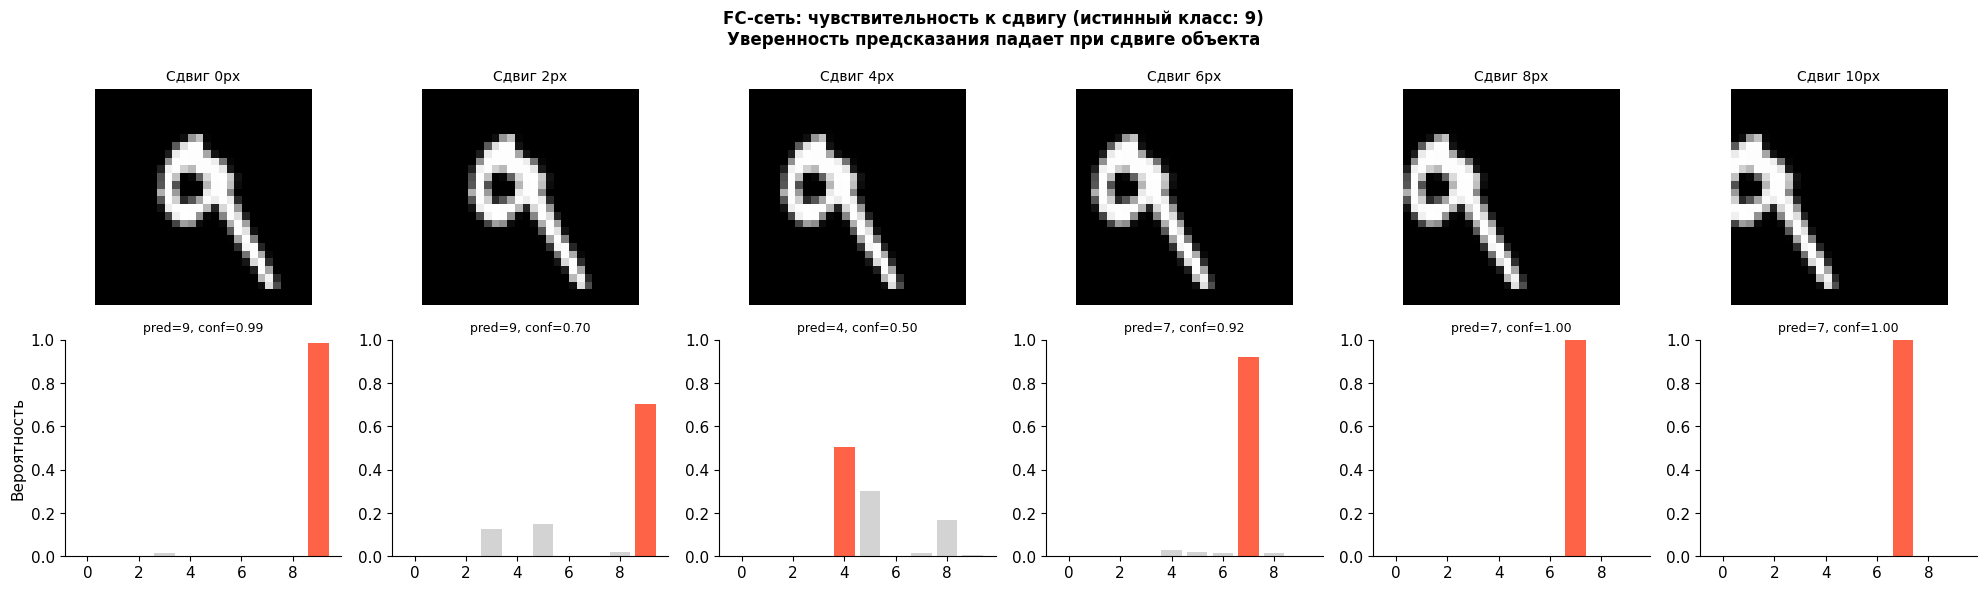

Результаты по сдвигам (pred, confidence):
  Сдвиг  0px: pred=9, conf=0.987  [OK]
  Сдвиг  2px: pred=9, conf=0.703  [OK]
  Сдвиг  4px: pred=4, conf=0.503  [ОШИБКА]
  Сдвиг  6px: pred=7, conf=0.922  [ОШИБКА]
  Сдвиг  8px: pred=7, conf=1.000  [ОШИБКА]
  Сдвиг 10px: pred=7, conf=1.000  [ОШИБКА]


In [6]:
# =============================================================
# Демонстрация: чувствительность FC-сети к сдвигу изображения
# =============================================================

fc_model.eval()

sample_img, sample_label = test_dataset[7]
shifts = [0, 2, 4, 6, 8, 10]

fig, axes = plt.subplots(2, len(shifts), figsize=(20, 6))

confidences = []
for i, shift in enumerate(shifts):
    shifted = torch.zeros_like(sample_img)
    if shift < 28:
        shifted[:, :, :28-shift] = sample_img[:, :, shift:]  # сдвиг влево

    with torch.no_grad():
        logits = fc_model(shifted.unsqueeze(0).to(device))
        probs  = F.softmax(logits, dim=1).squeeze().cpu().numpy()
    pred = probs.argmax()
    conf = probs[pred]
    confidences.append((pred, conf))

    axes[0, i].imshow(shifted.squeeze(), cmap='gray')
    axes[0, i].set_title(f'Сдвиг {shift}px', fontsize=10)
    axes[0, i].axis('off')

    axes[1, i].bar(range(10), probs, color=['tomato' if j==pred else 'lightgray' for j in range(10)])
    axes[1, i].set_title(f'pred={pred}, conf={conf:.2f}', fontsize=9)
    axes[1, i].set_ylim(0, 1)
    if i == 0:
        axes[1, i].set_ylabel('Вероятность')

plt.suptitle(f'FC-сеть: чувствительность к сдвигу (истинный класс: {sample_label})\n'
             'Уверенность предсказания падает при сдвиге объекта', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Результаты по сдвигам (pred, confidence):')
for shift, (pred, conf) in zip(shifts, confidences):
    marker = 'OK' if pred == sample_label else 'ОШИБКА'
    print(f'  Сдвиг {shift:2d}px: pred={pred}, conf={conf:.3f}  [{marker}]')

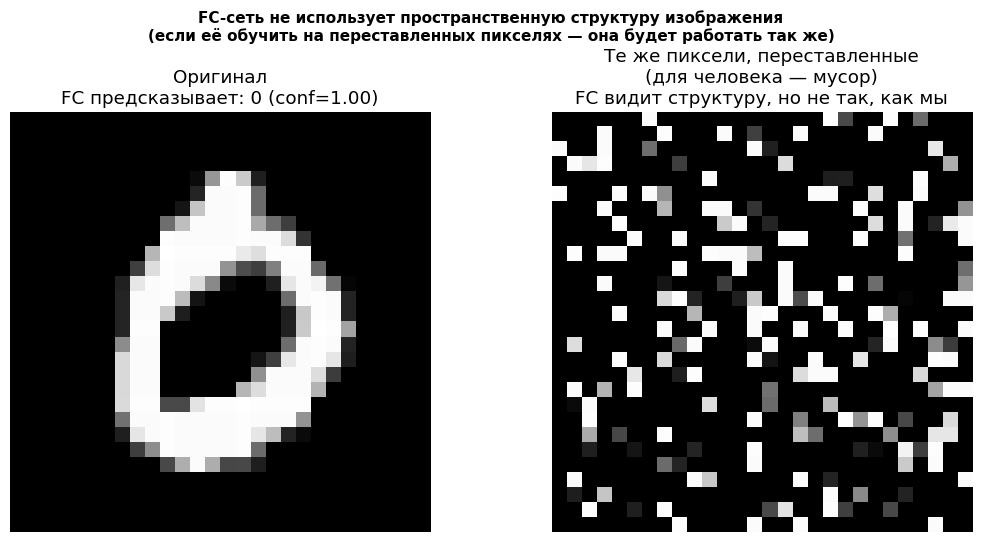

Важно: дело не в том, что FC-сеть "не сломается" на перестановке после обучения на оригинале
(она, конечно, ошибётся, так как видит непривычный паттерн).
Дело в другом: если ОБУЧИТЬ FC-сеть с нуля на последовательно переставленных пикселях,
она достигнет ТОЙ ЖЕ точности, что и на оригинальных изображениях.
Для CNN это невозможно — она явно использует соседство пикселей через свёртку.


In [7]:
# =============================================================
# Демонстрация: перестановка пикселей не меняет результат для FC
# =============================================================

# Создаём фиксированную случайную перестановку пикселей
rng = np.random.RandomState(0)
perm = rng.permutation(28*28)

def permute_image(img_tensor, perm):
    flat = img_tensor.view(-1)
    return flat[perm].view(img_tensor.shape)

sample_img2, sample_label2 = test_dataset[3]
permuted_img = permute_image(sample_img2, perm)

fc_model.eval()
with torch.no_grad():
    logits_orig = fc_model(sample_img2.unsqueeze(0).to(device))
    logits_perm = fc_model(permuted_img.unsqueeze(0).to(device))

probs_orig = F.softmax(logits_orig, dim=1).squeeze().cpu().numpy()
probs_perm = F.softmax(logits_perm, dim=1).squeeze().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
axes[0].imshow(sample_img2.squeeze(), cmap='gray')
axes[0].set_title(f'Оригинал\nFC предсказывает: {probs_orig.argmax()} (conf={probs_orig.max():.2f})')
axes[0].axis('off')

axes[1].imshow(permuted_img.squeeze(), cmap='gray')
axes[1].set_title(f'Те же пиксели, переставленные\n(для человека — мусор)\nFC видит структуру, но не так, как мы')
axes[1].axis('off')

plt.suptitle('FC-сеть не использует пространственную структуру изображения\n'
             '(если её обучить на переставленных пикселях — она будет работать так же)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('Важно: дело не в том, что FC-сеть "не сломается" на перестановке после обучения на оригинале')
print('(она, конечно, ошибётся, так как видит непривычный паттерн).')
print('Дело в другом: если ОБУЧИТЬ FC-сеть с нуля на последовательно переставленных пикселях,')
print('она достигнет ТОЙ ЖЕ точности, что и на оригинальных изображениях.')
print('Для CNN это невозможно — она явно использует соседство пикселей через свёртку.')

---

## Раздел 4: Операция свёртки с нуля

### Математика свёртки (точнее, кросс-корреляция)

$$(I * K)[i,j] = \sum_{m}\sum_{n} I[i+m, j+n] \cdot K[m,n]$$

Ядро (kernel) $K$ скользит по изображению $I$, в каждой позиции считается поэлементное произведение и сумма. Именно так свёрточный слой реализует local connectivity и parameter sharing, о которых шла речь в разделе 1: одно и то же ядро $K$ применяется ко всем позициям изображения.

In [8]:
# =============================================================
# Реализация 2D свёртки с нуля (без torch.nn.Conv2d)
# =============================================================

def conv2d_manual(image, kernel, stride=1, padding=0):
    """
    Наивная реализация 2D свёртки для понимания механики.
    image:  (H, W) numpy array
    kernel: (kh, kw) numpy array
    """
    if padding > 0:
        image = np.pad(image, padding, mode='constant', constant_values=0)

    H, W   = image.shape
    kh, kw = kernel.shape
    out_h  = (H - kh) // stride + 1
    out_w  = (W - kw) // stride + 1

    output = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            region = image[i*stride : i*stride+kh, j*stride : j*stride+kw]
            output[i, j] = np.sum(region * kernel)
    return output


test_img = img_np.copy()

sobel_x = np.array([[-1, 0, 1],
                     [-2, 0, 2],
                     [-1, 0, 1]], dtype=np.float32)

result_manual = conv2d_manual(test_img, sobel_x, stride=1, padding=1)

img_t    = torch.tensor(test_img).unsqueeze(0).unsqueeze(0).float()
kernel_t = torch.tensor(sobel_x).unsqueeze(0).unsqueeze(0).float()
result_torch = F.conv2d(img_t, kernel_t, padding=1).squeeze().numpy()

print(f'Своя реализация: форма {result_manual.shape}, диапазон [{result_manual.min():.2f}, {result_manual.max():.2f}]')
print(f'PyTorch Conv2d:  форма {result_torch.shape}, диапазон [{result_torch.min():.2f}, {result_torch.max():.2f}]')
print(f'Максимальная разница: {np.abs(result_manual - result_torch).max():.6f}  (должна быть ~0)')

Своя реализация: форма (28, 28), диапазон [-3.92, 3.72]
PyTorch Conv2d:  форма (28, 28), диапазон [-3.92, 3.72]
Максимальная разница: 0.000000  (должна быть ~0)


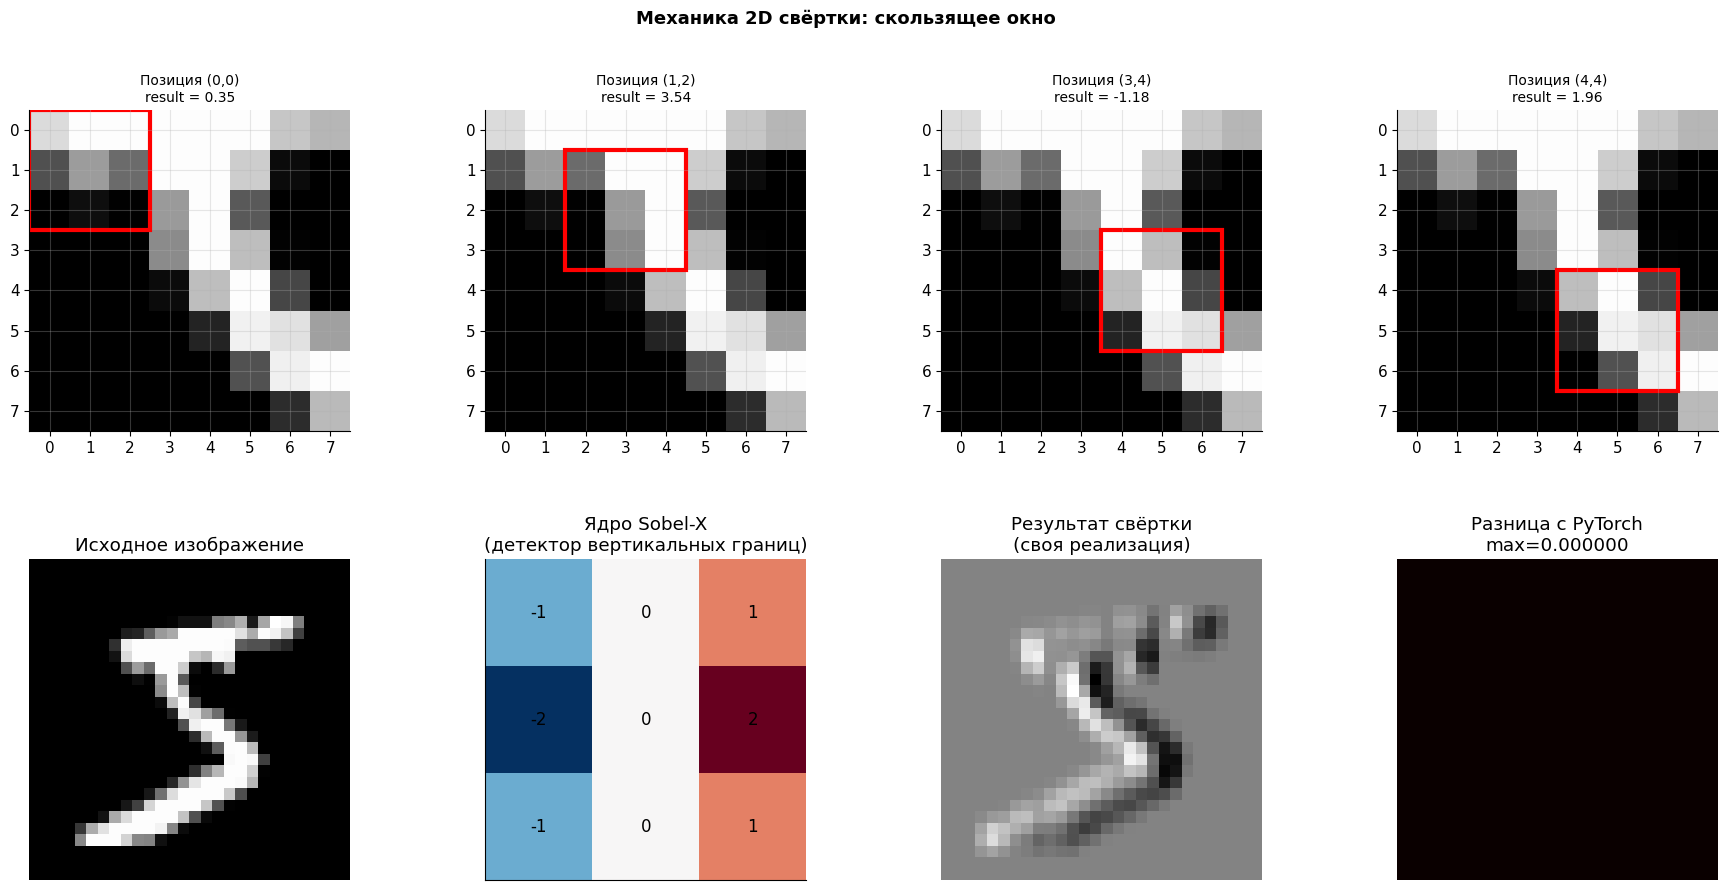

In [9]:
# =============================================================
# Визуализация механики свёртки: скользящее окно
# =============================================================

fig = plt.figure(figsize=(22, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.4, wspace=0.35)

small_img = test_img[8:16, 8:16]
small_kernel = sobel_x

positions = [(0,0), (1,2), (3,4), (4,4)]
for idx, (pi, pj) in enumerate(positions):
    ax = fig.add_subplot(gs[0, idx])
    ax.imshow(small_img, cmap='gray', vmin=0, vmax=1)
    rect = Rectangle((pj-0.5, pi-0.5), 3, 3, linewidth=3, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    region = small_img[pi:pi+3, pj:pj+3]
    conv_val = np.sum(region * small_kernel)
    ax.set_title(f'Позиция ({pi},{pj})\nresult = {conv_val:.2f}', fontsize=10)
    ax.set_xticks(range(8)); ax.set_yticks(range(8))
    ax.grid(True, alpha=0.3)

ax_full1 = fig.add_subplot(gs[1, 0])
ax_full1.imshow(test_img, cmap='gray')
ax_full1.set_title('Исходное изображение')
ax_full1.axis('off')

ax_full2 = fig.add_subplot(gs[1, 1])
ax_full2.imshow(sobel_x, cmap='RdBu_r', vmin=-2, vmax=2)
for i in range(3):
    for j in range(3):
        ax_full2.text(j, i, f'{sobel_x[i,j]:.0f}', ha='center', va='center', fontsize=12)
ax_full2.set_title('Ядро Sobel-X\n(детектор вертикальных границ)')
ax_full2.set_xticks([]); ax_full2.set_yticks([])

ax_full3 = fig.add_subplot(gs[1, 2])
ax_full3.imshow(result_manual, cmap='gray')
ax_full3.set_title('Результат свёртки\n(своя реализация)')
ax_full3.axis('off')

ax_full4 = fig.add_subplot(gs[1, 3])
diff = np.abs(result_manual - result_torch)
ax_full4.imshow(diff, cmap='hot', vmin=0, vmax=0.01)
ax_full4.set_title(f'Разница с PyTorch\nmax={diff.max():.6f}')
ax_full4.axis('off')

plt.suptitle('Механика 2D свёртки: скользящее окно', fontsize=13, fontweight='bold')
plt.show()

---

## Раздел 5: Классические ядра свёртки

До эпохи deep learning инженеры вручную проектировали ядра свёртки для конкретных задач. CNN же обучает эти ядра автоматически под конкретную задачу — это и есть главная идея свёрточных слоёв. Полезно увидеть классические ядра, чтобы понимать, что вообще "ищут" свёрточные фильтры.

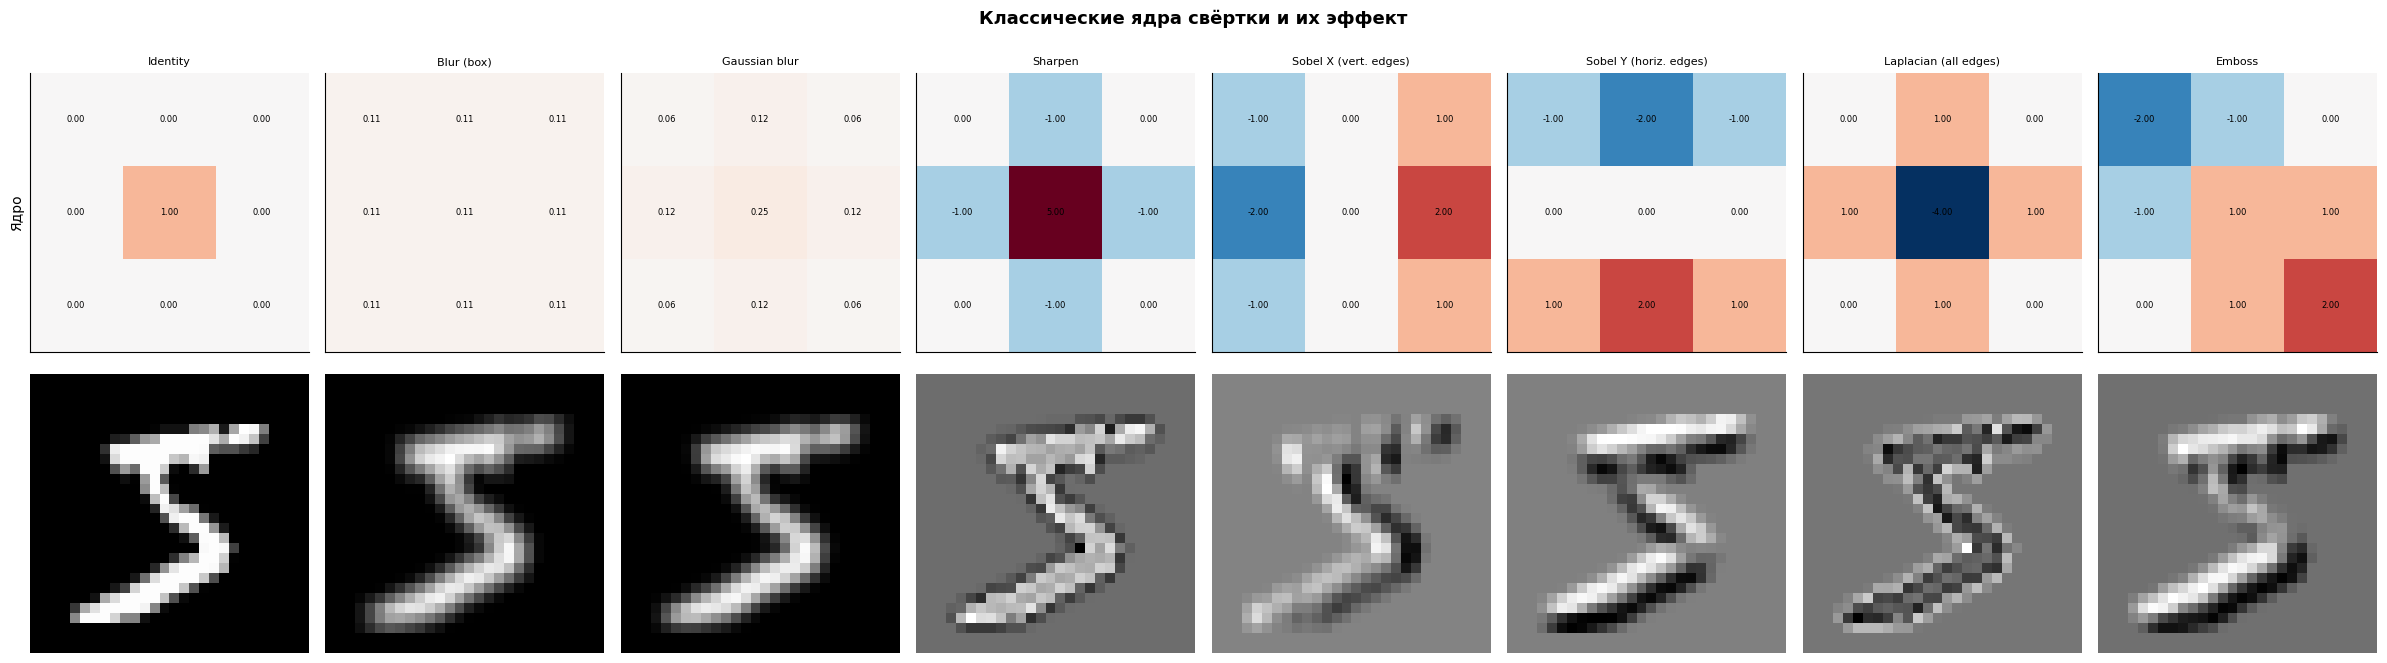

В обучаемой CNN такие ядра не задаются вручную —
сеть находит оптимальные веса фильтров через backpropagation.


In [10]:
# =============================================================
# Классические ядра свёртки
# =============================================================

kernels = {
    'Identity': np.array([[0,0,0],[0,1,0],[0,0,0]], dtype=np.float32),
    'Blur (box)': np.ones((3,3), dtype=np.float32) / 9,
    'Gaussian blur': np.array([[1,2,1],[2,4,2],[1,2,1]], dtype=np.float32) / 16,
    'Sharpen': np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=np.float32),
    'Sobel X (vert. edges)': np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float32),
    'Sobel Y (horiz. edges)': np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=np.float32),
    'Laplacian (all edges)': np.array([[0,1,0],[1,-4,1],[0,1,0]], dtype=np.float32),
    'Emboss': np.array([[-2,-1,0],[-1,1,1],[0,1,2]], dtype=np.float32),
}

fig, axes = plt.subplots(2, 8, figsize=(24, 7))
img_t = torch.tensor(test_img).unsqueeze(0).unsqueeze(0).float()

for idx, (name, kernel) in enumerate(kernels.items()):
    kernel_t = torch.tensor(kernel).unsqueeze(0).unsqueeze(0)
    result   = F.conv2d(img_t, kernel_t, padding=1).squeeze().numpy()

    axes[0, idx].imshow(kernel, cmap='RdBu_r', vmin=-3, vmax=3)
    for i in range(kernel.shape[0]):
        for j in range(kernel.shape[1]):
            axes[0, idx].text(j, i, f'{kernel[i,j]:.2f}', ha='center', va='center', fontsize=6)
    axes[0, idx].set_title(name, fontsize=8)
    axes[0, idx].set_xticks([]); axes[0, idx].set_yticks([])

    axes[1, idx].imshow(result, cmap='gray')
    axes[1, idx].axis('off')

axes[0,0].set_ylabel('Ядро', fontsize=10)
axes[1,0].set_ylabel('Результат', fontsize=10)
plt.suptitle('Классические ядра свёртки и их эффект', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('В обучаемой CNN такие ядра не задаются вручную —')
print('сеть находит оптимальные веса фильтров через backpropagation.')

---

## Раздел 6: Padding, Stride, Pooling

### Padding (отступы)

Без padding каждая свёртка уменьшает размер изображения. После нескольких слоёв изображение "съедается". Padding добавляет нули по краям, сохраняя размер.

$$\text{output\_size} = \left\lfloor \frac{H + 2P - K}{S} \right\rfloor + 1$$

где $H$ — размер входа, $P$ — padding, $K$ — размер ядра, $S$ — stride.

### Stride (шаг)

Шаг скольжения окна. `stride=2` уменьшает выходной размер вдвое — альтернатива pooling для downsampling.

### Pooling

Снижает размерность feature map, сохраняя главную информацию:
- Max pooling: берёт максимум в окне — сохраняет самые сильные активации
- Average pooling: берёт среднее — более плавный downsampling

Pooling также даёт некоторую инвариантность к небольшим сдвигам объекта — частично решает проблему, которую мы видели у FC-сети в разделе 3.

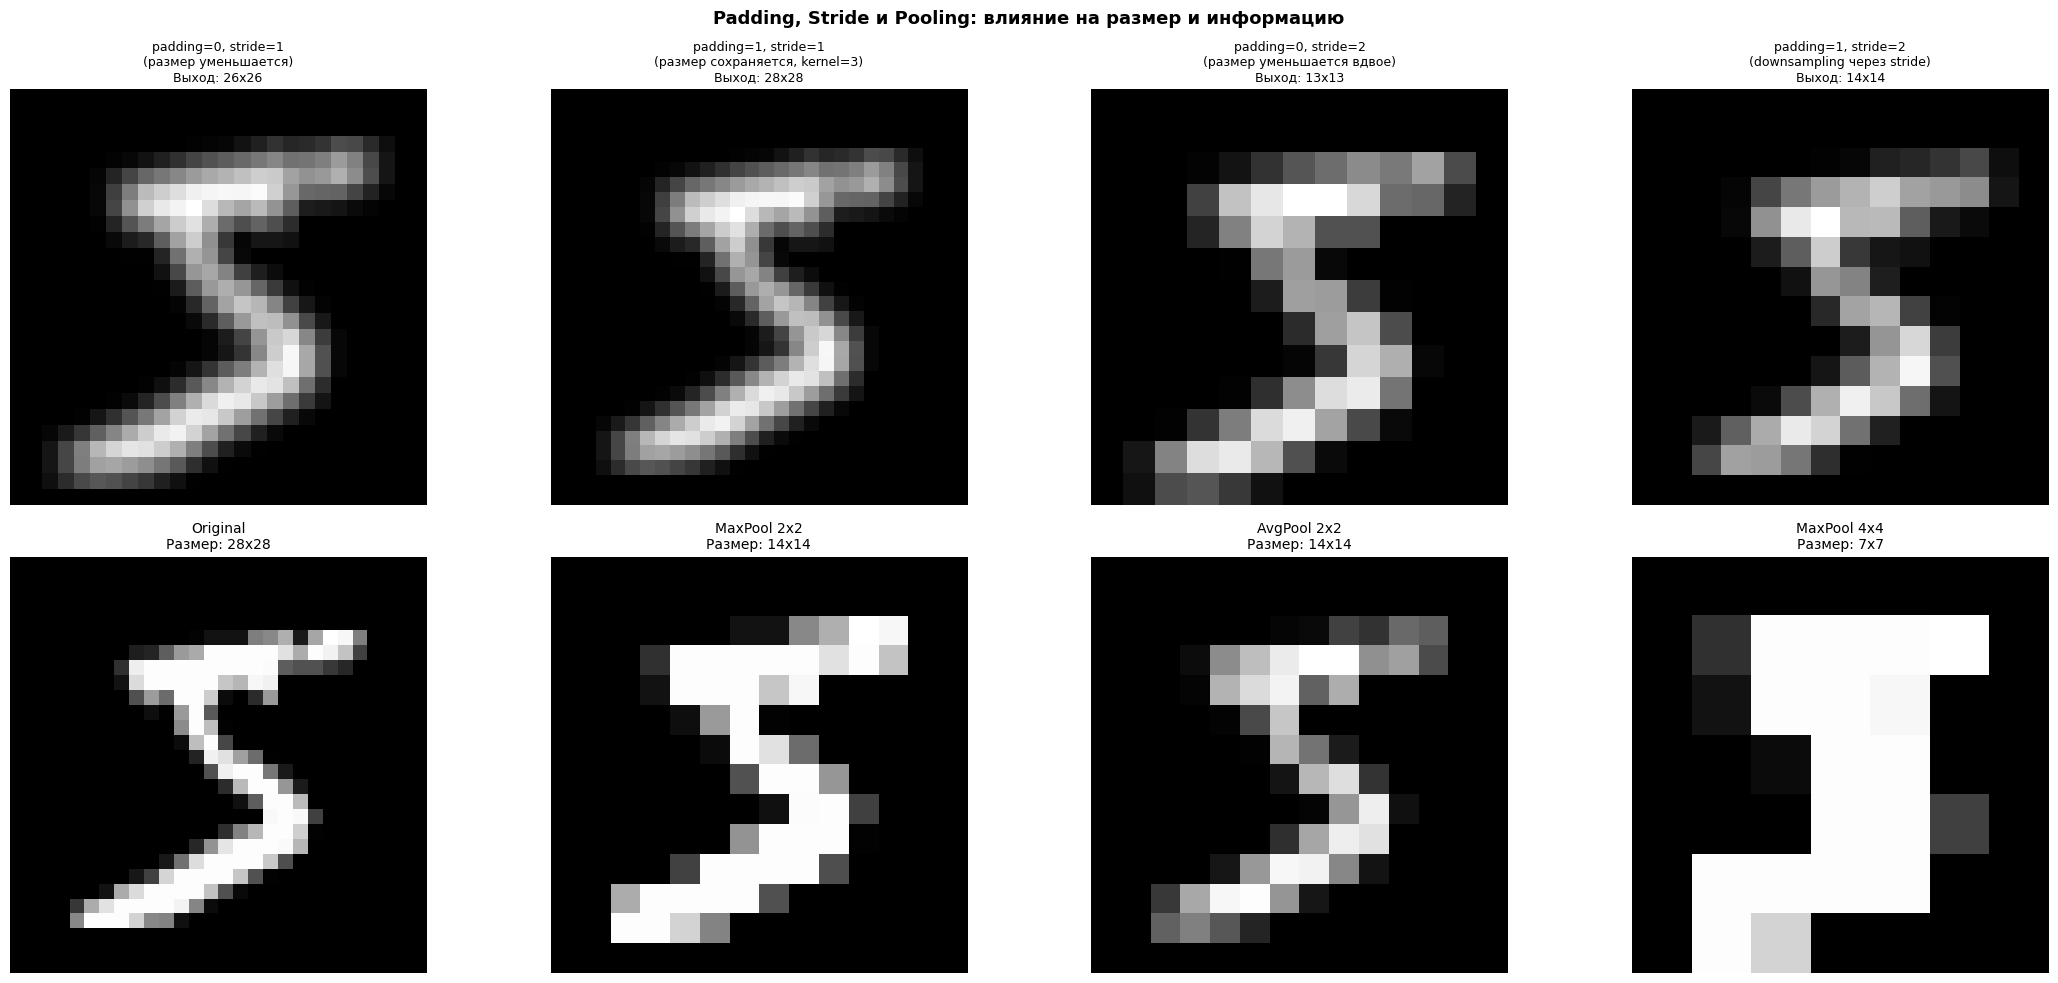

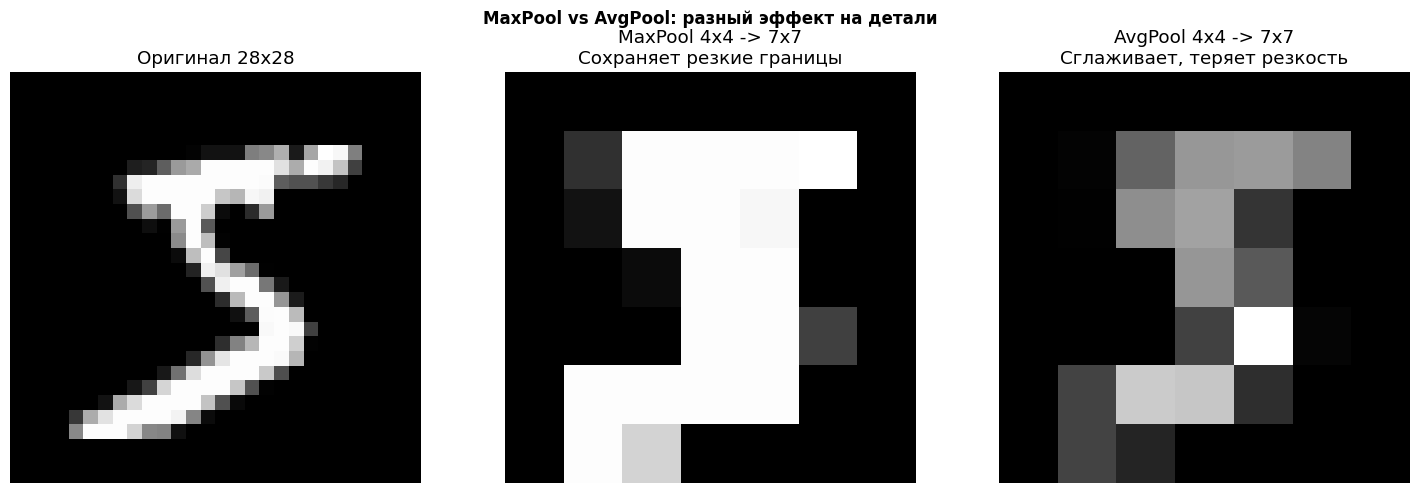

In [11]:
# =============================================================
# Визуализация: влияние padding, stride и pooling на размер
# =============================================================

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
img_batch = img_t

configs = [
    {'padding': 0, 'stride': 1, 'title': 'padding=0, stride=1\n(размер уменьшается)'},
    {'padding': 1, 'stride': 1, 'title': 'padding=1, stride=1\n(размер сохраняется, kernel=3)'},
    {'padding': 0, 'stride': 2, 'title': 'padding=0, stride=2\n(размер уменьшается вдвое)'},
    {'padding': 1, 'stride': 2, 'title': 'padding=1, stride=2\n(downsampling через stride)'},
]

kernel_demo = torch.ones(1,1,3,3) / 9

for idx, cfg in enumerate(configs):
    out = F.conv2d(img_batch, kernel_demo, padding=cfg['padding'], stride=cfg['stride'])
    axes[0, idx].imshow(out.squeeze().numpy(), cmap='gray')
    axes[0, idx].set_title(f"{cfg['title']}\nВыход: {out.shape[-2]}x{out.shape[-1]}", fontsize=9)
    axes[0, idx].axis('off')

pool_configs = [
    ('Original', lambda x: x, '28x28'),
    ('MaxPool 2x2', lambda x: F.max_pool2d(x, 2), '14x14'),
    ('AvgPool 2x2', lambda x: F.avg_pool2d(x, 2), '14x14'),
    ('MaxPool 4x4', lambda x: F.max_pool2d(x, 4), '7x7'),
]

for idx, (name, fn, size_str) in enumerate(pool_configs):
    out = fn(img_batch)
    axes[1, idx].imshow(out.squeeze().numpy(), cmap='gray')
    axes[1, idx].set_title(f'{name}\nРазмер: {size_str}', fontsize=10)
    axes[1, idx].axis('off')

plt.suptitle('Padding, Stride и Pooling: влияние на размер и информацию', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_np, cmap='gray')
axes[0].set_title('Оригинал 28x28')
axes[0].axis('off')

maxp = F.max_pool2d(img_batch, 4).squeeze().numpy()
avgp = F.avg_pool2d(img_batch, 4).squeeze().numpy()

axes[1].imshow(maxp, cmap='gray')
axes[1].set_title('MaxPool 4x4 -> 7x7\nСохраняет резкие границы')
axes[1].axis('off')

axes[2].imshow(avgp, cmap='gray')
axes[2].set_title('AvgPool 4x4 -> 7x7\nСглаживает, теряет резкость')
axes[2].axis('off')

plt.suptitle('MaxPool vs AvgPool: разный эффект на детали', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Раздел 7: CNN-классификатор на PyTorch

Соберём типичную свёрточную сеть: чередование Conv -> BatchNorm -> ReLU -> Pooling, в конце Global Average Pooling и Linear-классификатор.

### Зачем BatchNorm?

Нормализует активации каждого слоя — стабилизирует и ускоряет обучение, позволяет использовать больший learning rate.

### Зачем Global Average Pooling вместо Flatten?

Flatten перед Linear создаёт много параметров и привязывает сеть к конкретному размеру входа. GlobalAveragePooling сжимает каждый feature map в одно число — компактно и работает с любым размером входа.

In [13]:
# =============================================================
# CNN-классификатор
# =============================================================

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),


# Каждое из этих 32 ядер делает свою отдельную свёртку входного изображения и выдаёт свою отдельную карту признаков
# (feature map) размером 28x28.
# На выходе мы складываем все 32 такие карты вместе — получаем тензор 32x28x28


            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x).flatten(1)
        return self.classifier(x)

    def forward_with_features(self, x):
        feats = []
        for layer in self.features:
            x = layer(x)
            if isinstance(layer, nn.Conv2d):
                feats.append(x.detach())
        gap_out = self.gap(x).flatten(1)
        logits  = self.classifier(gap_out)
        return logits, feats


cnn_model = SimpleCNN(num_classes=10).to(device)
n_params_cnn = sum(p.numel() for p in cnn_model.parameters())

print('Архитектура CNN:')
print(cnn_model)
print(f'\nВсего параметров CNN: {n_params_cnn:,}')
print(f'Всего параметров FC:  {n_params_fc:,}')
print(f'CNN использует в {n_params_fc/n_params_cnn:.1f}x МЕНЬШЕ параметров, чем FC-сеть')

dummy = torch.randn(4, 1, 28, 28).to(device)
out   = cnn_model(dummy)
print(f'\nВход: {dummy.shape} -> Выход: {out.shape}')

Архитектура CNN:
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1

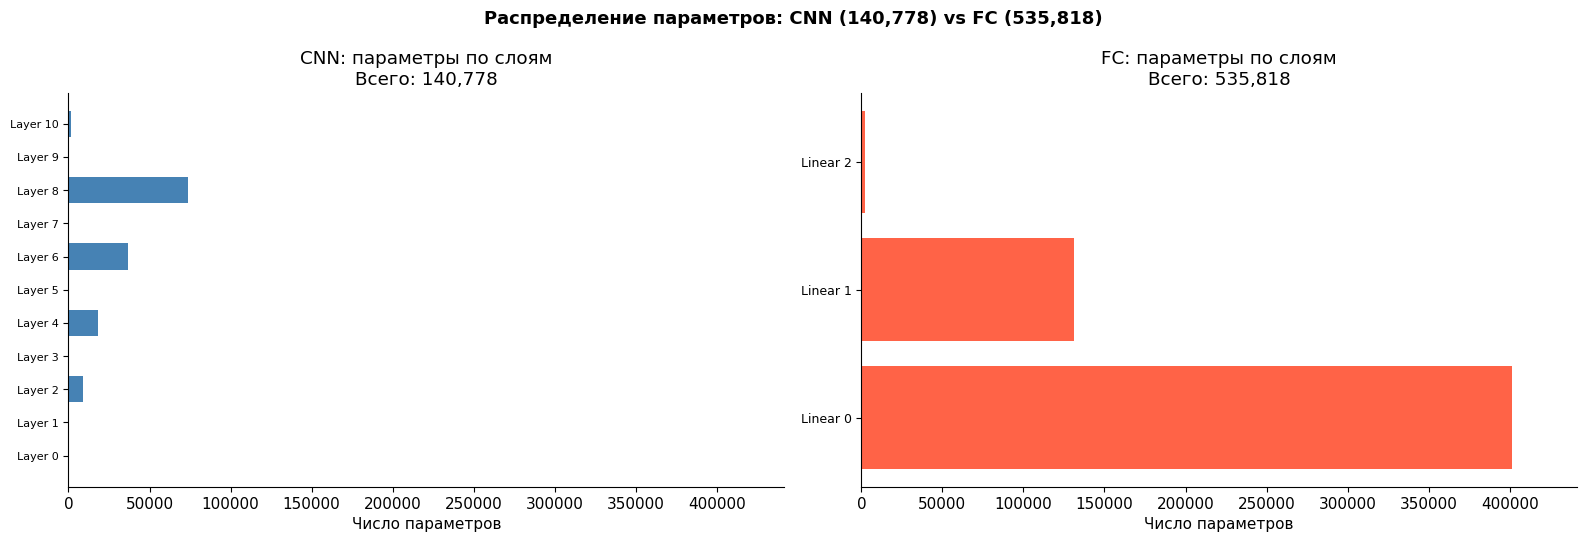

Большая часть параметров FC-сети сосредоточена в первом слое (784 -> 512),
потому что туда подаётся целиком развёрнутое изображение.
У CNN параметры распределены равномернее по глубине благодаря parameter sharing.


In [14]:
# =============================================================
# Визуализация: параметры по слоям, CNN vs FC
# =============================================================

cnn_params_by_layer = [(name, p.numel()) for name, p in cnn_model.named_parameters() if 'weight' in name]
fc_params_by_layer  = [(name, p.numel()) for name, p in fc_model.named_parameters()  if 'weight' in name]

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

vals_cnn = [v for _, v in cnn_params_by_layer]
axes[0].barh(range(len(vals_cnn)), vals_cnn, color='steelblue')
axes[0].set_yticks(range(len(vals_cnn)))
axes[0].set_yticklabels([f'Layer {i}' for i in range(len(vals_cnn))], fontsize=8)
axes[0].set_xlabel('Число параметров')
axes[0].set_title(f'CNN: параметры по слоям\nВсего: {n_params_cnn:,}')

names_fc = [f'Linear {i}' for i in range(len(fc_params_by_layer))]
vals_fc  = [v for _, v in fc_params_by_layer]
axes[1].barh(range(len(vals_fc)), vals_fc, color='tomato')
axes[1].set_yticks(range(len(vals_fc)))
axes[1].set_yticklabels(names_fc, fontsize=9)
axes[1].set_xlabel('Число параметров')
axes[1].set_title(f'FC: параметры по слоям\nВсего: {n_params_fc:,}')

max_val = max(max(vals_cnn), max(vals_fc))
axes[0].set_xlim(0, max_val*1.1)
axes[1].set_xlim(0, max_val*1.1)

plt.suptitle(f'Распределение параметров: CNN ({n_params_cnn:,}) vs FC ({n_params_fc:,})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Большая часть параметров FC-сети сосредоточена в первом слое (784 -> 512),')
print('потому что туда подаётся целиком развёрнутое изображение.')
print('У CNN параметры распределены равномернее по глубине благодаря parameter sharing.')

---

## Раздел 8: Обучение и прямое сравнение CNN vs FC

In [15]:
# =============================================================
# Обучение CNN (тот же протокол, что и для FC, для честного сравнения)
# =============================================================

opt_cnn = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)
sched_cnn = torch.optim.lr_scheduler.StepLR(opt_cnn, step_size=3, gamma=0.5)

hist_cnn = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f'Обучаем CNN ({N_EPOCHS} эпох, тот же протокол, что для FC)...')
for epoch in tqdm(range(N_EPOCHS), desc='CNN'):
    tl, ta = train_epoch(cnn_model, train_loader, opt_cnn, criterion, device)
    vl, va = evaluate(cnn_model, test_loader, criterion, device)
    sched_cnn.step()
    hist_cnn['train_loss'].append(tl); hist_cnn['train_acc'].append(ta)
    hist_cnn['val_loss'].append(vl);   hist_cnn['val_acc'].append(va)
    print(f'  Эпоха {epoch+1}: train_acc={ta:.4f}  val_acc={va:.4f}')

print(f'\nИтоговая точность CNN на тесте: {hist_cnn["val_acc"][-1]*100:.2f}%')
print(f'Итоговая точность FC на тесте:  {hist_fc["val_acc"][-1]*100:.2f}%')

Обучаем CNN (6 эпох, тот же протокол, что для FC)...


CNN:   0%|          | 0/6 [00:00<?, ?it/s]

  Эпоха 1: train_acc=0.9523  val_acc=0.9817
  Эпоха 2: train_acc=0.9883  val_acc=0.9859
  Эпоха 3: train_acc=0.9917  val_acc=0.9709
  Эпоха 4: train_acc=0.9951  val_acc=0.9929
  Эпоха 5: train_acc=0.9966  val_acc=0.9925
  Эпоха 6: train_acc=0.9972  val_acc=0.9911

Итоговая точность CNN на тесте: 99.11%
Итоговая точность FC на тесте:  97.71%


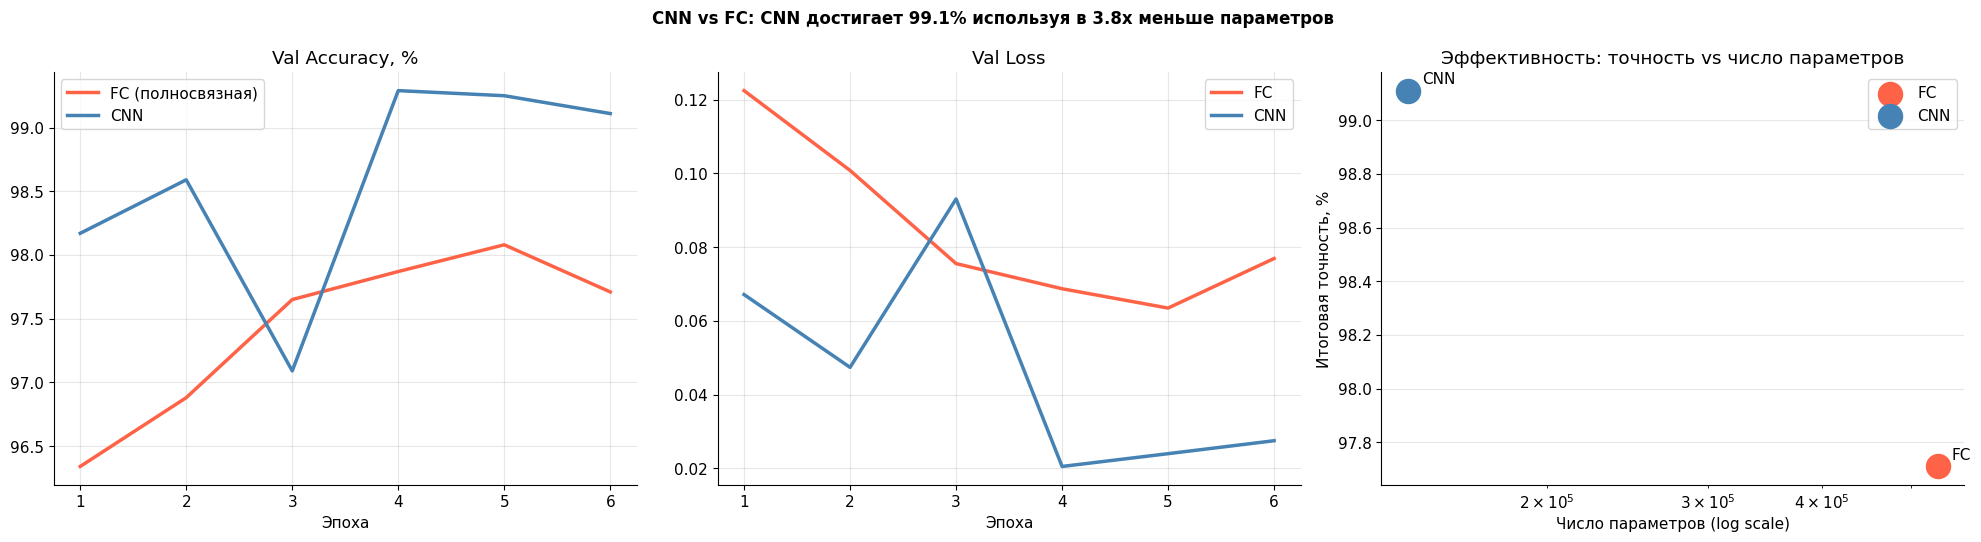

In [16]:
# =============================================================
# Прямое сравнение кривых обучения CNN vs FC
# =============================================================

ep = range(1, N_EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

axes[0].plot(ep, [a*100 for a in hist_fc['val_acc']],  lw=2.5, color='tomato',   label='FC (полносвязная)')
axes[0].plot(ep, [a*100 for a in hist_cnn['val_acc']], lw=2.5, color='steelblue', label='CNN')
axes[0].set_title('Val Accuracy, %'); axes[0].set_xlabel('Эпоха')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, hist_fc['val_loss'],  lw=2.5, color='tomato',   label='FC')
axes[1].plot(ep, hist_cnn['val_loss'], lw=2.5, color='steelblue', label='CNN')
axes[1].set_title('Val Loss'); axes[1].set_xlabel('Эпоха')
axes[1].legend(); axes[1].grid(alpha=0.3)

ax = axes[2]
ax.scatter([n_params_fc], [hist_fc['val_acc'][-1]*100], s=300, color='tomato', label='FC', zorder=5)
ax.scatter([n_params_cnn], [hist_cnn['val_acc'][-1]*100], s=300, color='steelblue', label='CNN', zorder=5)
ax.annotate('FC', (n_params_fc, hist_fc['val_acc'][-1]*100), textcoords='offset points', xytext=(10,5))
ax.annotate('CNN', (n_params_cnn, hist_cnn['val_acc'][-1]*100), textcoords='offset points', xytext=(10,5))
ax.set_xlabel('Число параметров (log scale)')
ax.set_ylabel('Итоговая точность, %')
ax.set_xscale('log')
ax.set_title('Эффективность: точность vs число параметров')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle(f'CNN vs FC: CNN достигает {hist_cnn["val_acc"][-1]*100:.1f}% используя в '
             f'{n_params_fc/n_params_cnn:.1f}x меньше параметров',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

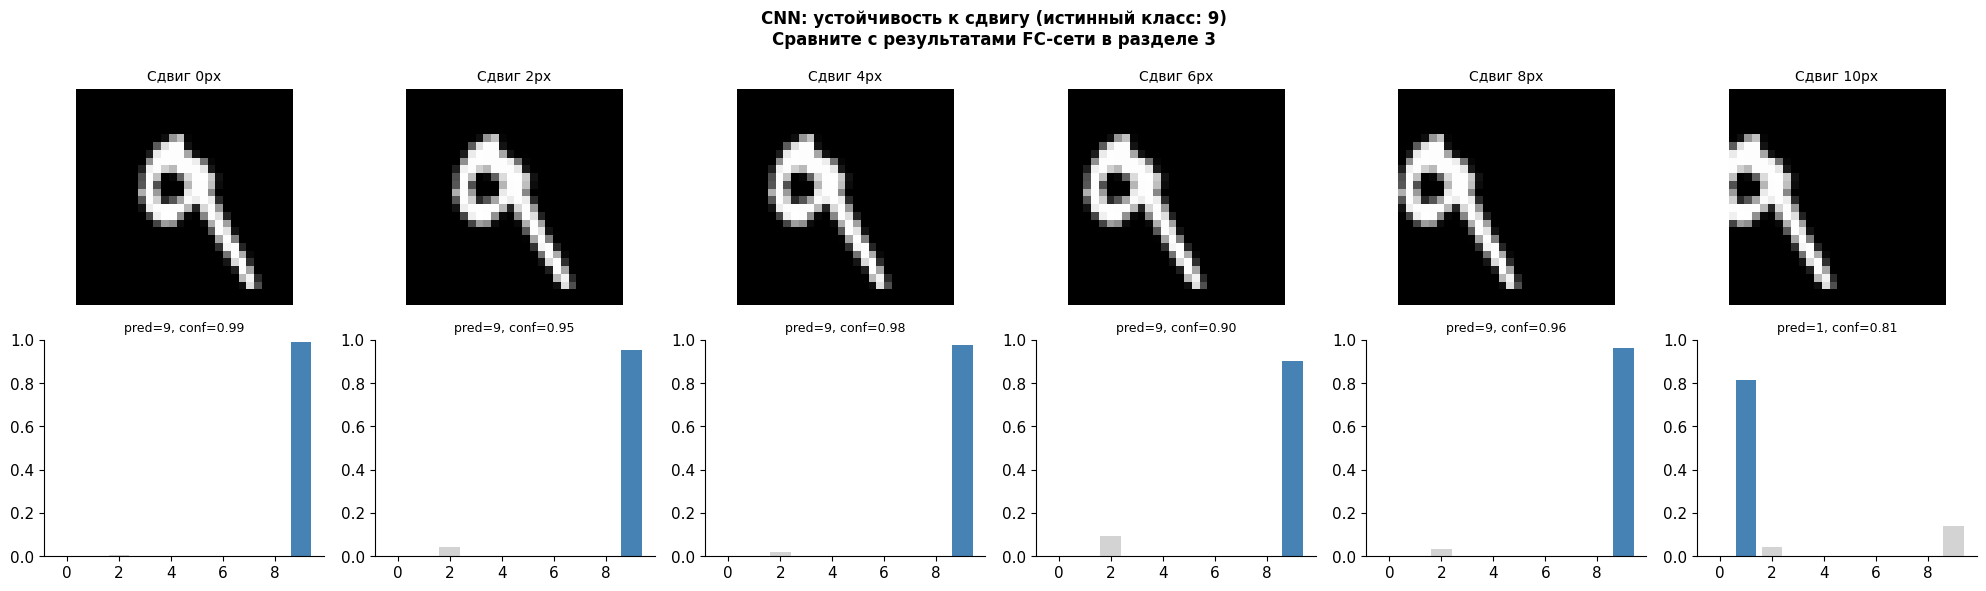

Сравнение уверенности предсказания при сдвиге (FC vs CNN):
Сдвиг   FC pred   FC conf   CNN pred  CNN conf  
0       9         0.987     9         0.991     
2       9         0.703     9         0.953     
4       4         0.503     9         0.978     
6       7         0.922     9         0.904     
8       7         1.000     9         0.963     
10      7         1.000     1         0.813     


In [17]:
# =============================================================
# Повторяем тест на сдвиг для CNN и сравниваем с FC
# =============================================================

cnn_model.eval()

fig, axes = plt.subplots(2, len(shifts), figsize=(20, 6))

confidences_cnn = []
for i, shift in enumerate(shifts):
    shifted = torch.zeros_like(sample_img)
    if shift < 28:
        shifted[:, :, :28-shift] = sample_img[:, :, shift:]

    with torch.no_grad():
        logits = cnn_model(shifted.unsqueeze(0).to(device))
        probs  = F.softmax(logits, dim=1).squeeze().cpu().numpy()
    pred = probs.argmax()
    conf = probs[pred]
    confidences_cnn.append((pred, conf))

    axes[0, i].imshow(shifted.squeeze(), cmap='gray')
    axes[0, i].set_title(f'Сдвиг {shift}px', fontsize=10)
    axes[0, i].axis('off')

    axes[1, i].bar(range(10), probs, color=['steelblue' if j==pred else 'lightgray' for j in range(10)])
    axes[1, i].set_title(f'pred={pred}, conf={conf:.2f}', fontsize=9)
    axes[1, i].set_ylim(0, 1)

plt.suptitle(f'CNN: устойчивость к сдвигу (истинный класс: {sample_label})\n'
             'Сравните с результатами FC-сети в разделе 3', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Сравнение уверенности предсказания при сдвиге (FC vs CNN):')
print(f'{"Сдвиг":<8}{"FC pred":<10}{"FC conf":<10}{"CNN pred":<10}{"CNN conf":<10}')
for shift, (fp,fc), (cp,cc) in zip(shifts, confidences, confidences_cnn):
    print(f'{shift:<8}{fp:<10}{fc:<10.3f}{cp:<10}{cc:<10.3f}')

---

## Раздел 9: Визуализация feature maps и выученных фильтров

Что именно "видят" разные слои CNN? Ранние слои реагируют на простые паттерны (границы, углы), глубокие слои — на сложные, абстрактные признаки.

Истинный класс: 9  |  Предсказание: 9
Число conv-слоёв с сохранёнными feature maps: 5
  Слой 1: форма (32, 28, 28)
  Слой 2: форма (32, 28, 28)
  Слой 3: форма (64, 14, 14)
  Слой 4: форма (64, 14, 14)
  Слой 5: форма (128, 7, 7)


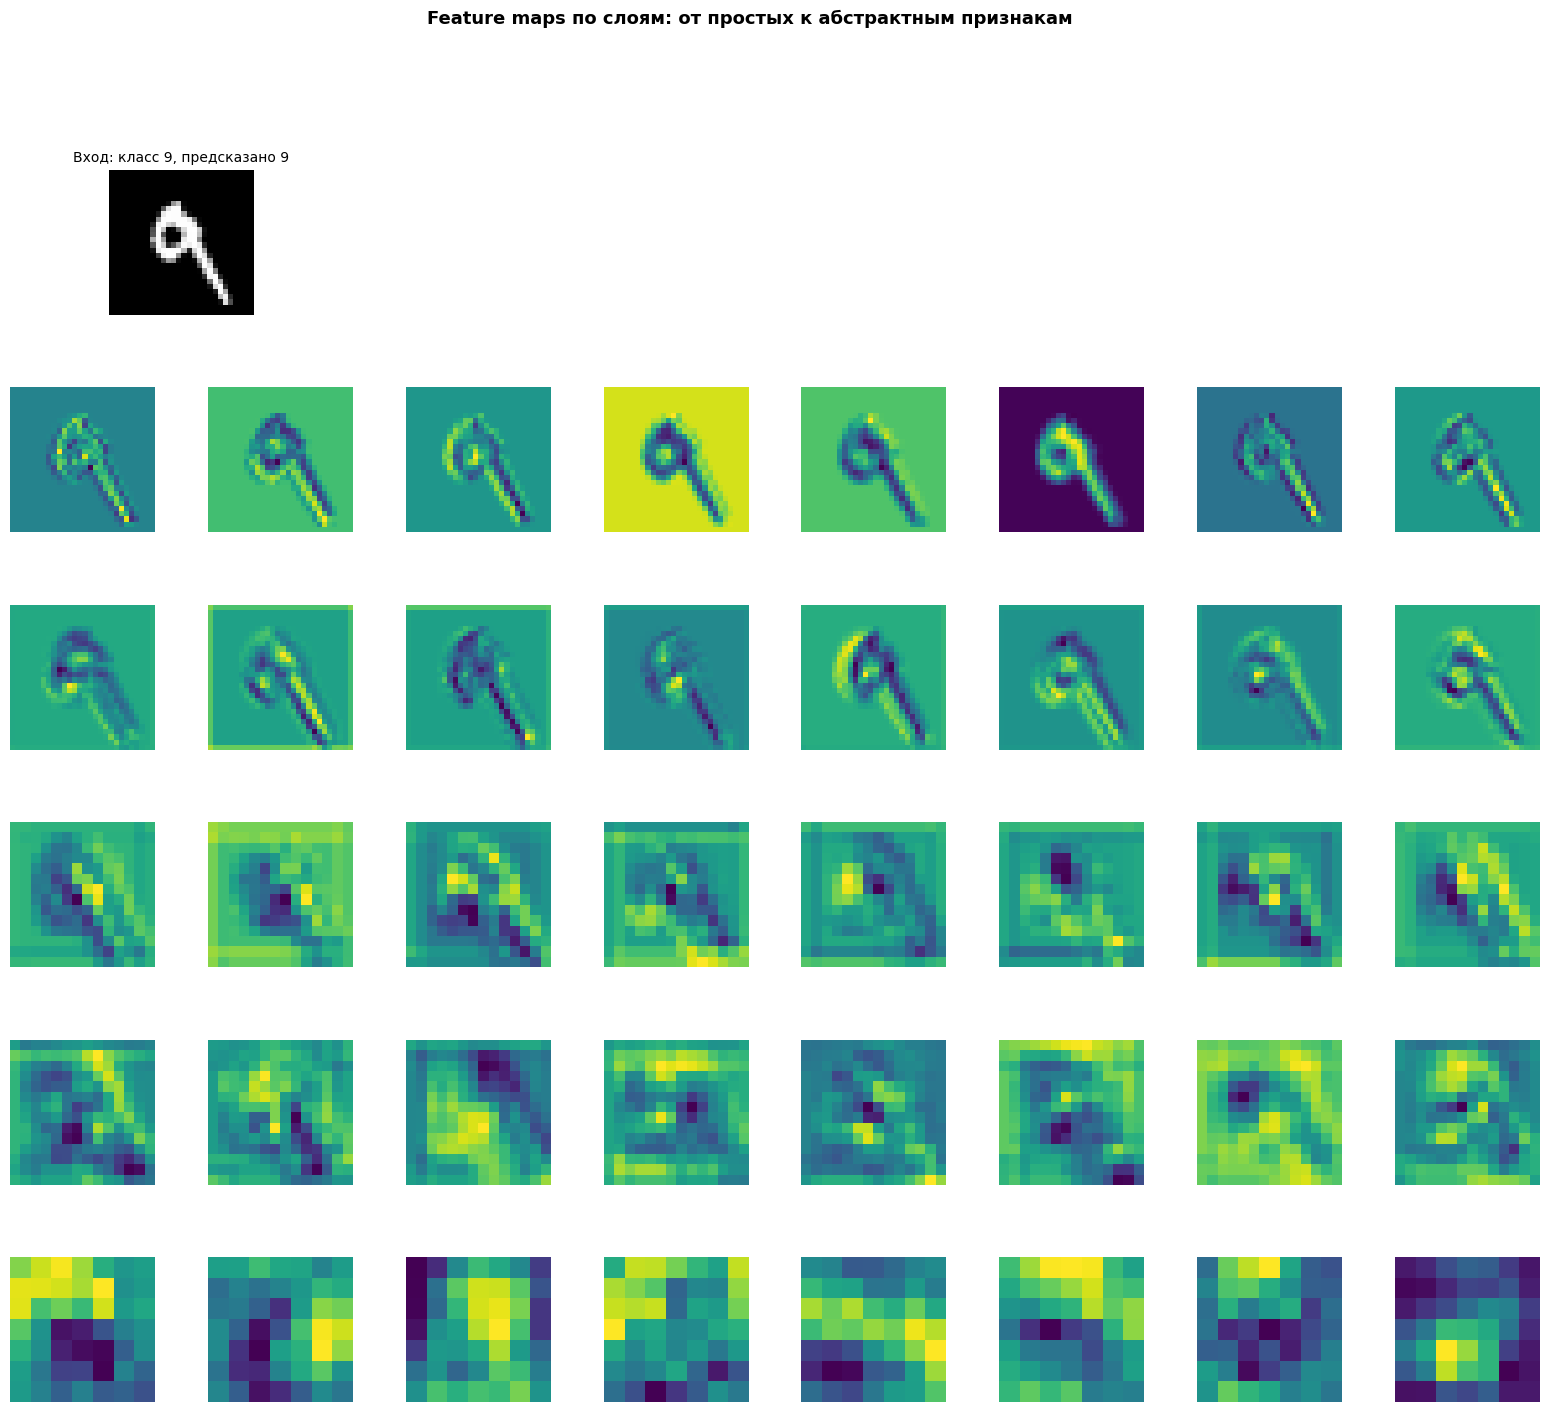

In [18]:
# =============================================================
# Визуализация feature maps по слоям
# =============================================================

cnn_model.eval()
sample_img_fm, sample_label_fm = test_dataset[7]
sample_batch = sample_img_fm.unsqueeze(0).to(device)

with torch.no_grad():
    logits, feat_maps = cnn_model.forward_with_features(sample_batch)
pred = logits.argmax(1).item()

print(f'Истинный класс: {sample_label_fm}  |  Предсказание: {pred}')
print(f'Число conv-слоёв с сохранёнными feature maps: {len(feat_maps)}')
for i, fm in enumerate(feat_maps):
    print(f'  Слой {i+1}: форма {tuple(fm.shape[1:])}')

fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(len(feat_maps) + 1, 8, figure=fig, hspace=0.5, wspace=0.2)

ax0 = fig.add_subplot(gs[0, :2])
ax0.imshow(sample_img_fm.squeeze(), cmap='gray')
ax0.set_title(f'Вход: класс {sample_label_fm}, предсказано {pred}', fontsize=10)
ax0.axis('off')

for layer_idx, fm in enumerate(feat_maps):
    fm_np = fm.squeeze(0).cpu().numpy()
    n_show = min(8, fm_np.shape[0])
    for ch in range(n_show):
        ax = fig.add_subplot(gs[layer_idx + 1, ch])
        ax.imshow(fm_np[ch], cmap='viridis')
        ax.axis('off')
        if ch == 0:
            ax.set_ylabel(f'Conv {layer_idx+1}\n{fm_np.shape[1]}x{fm_np.shape[2]}', fontsize=9)

plt.suptitle('Feature maps по слоям: от простых к абстрактным признакам', fontsize=13, fontweight='bold')
plt.show()

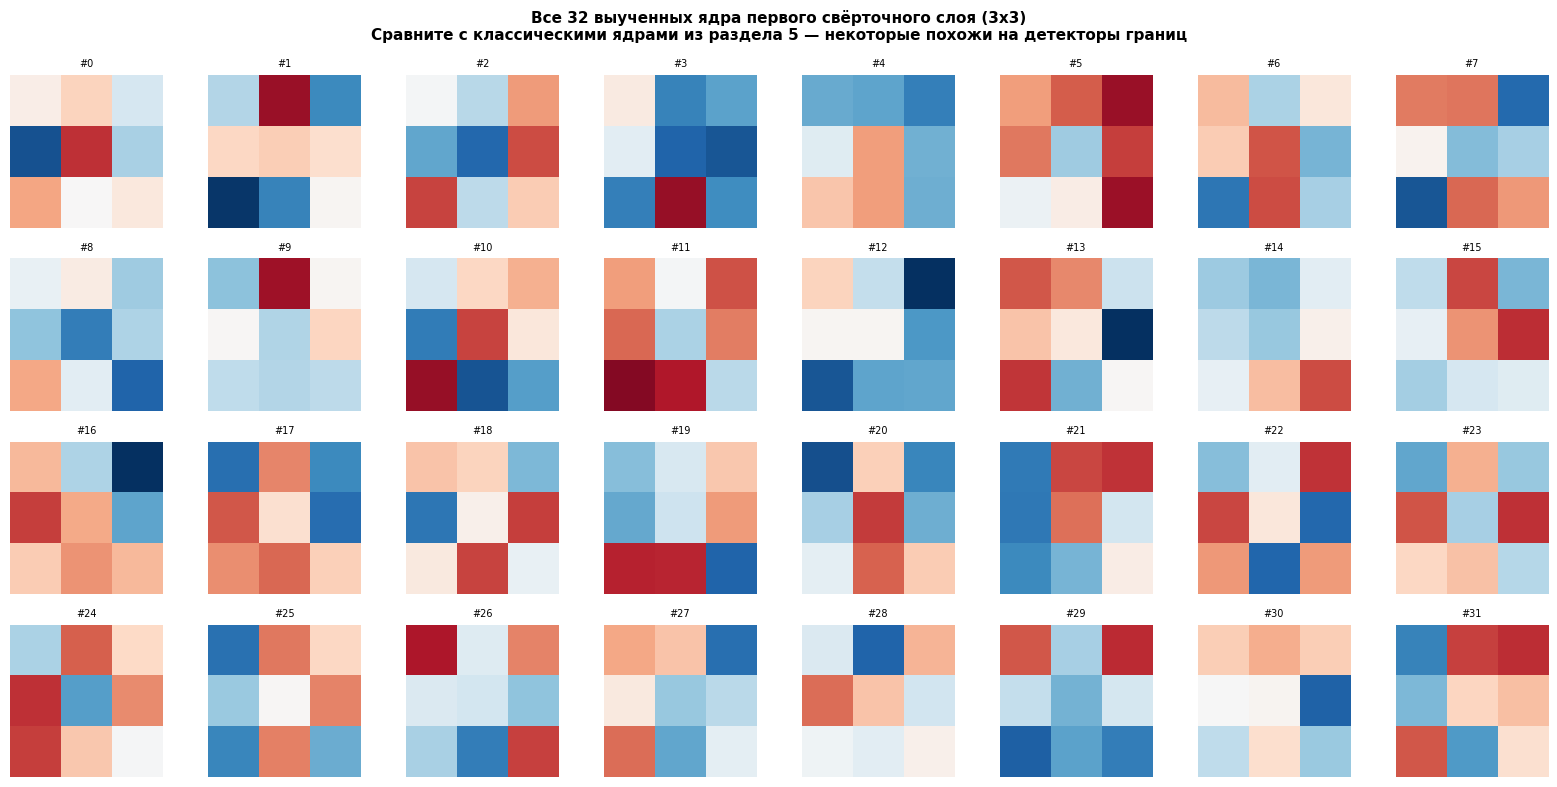

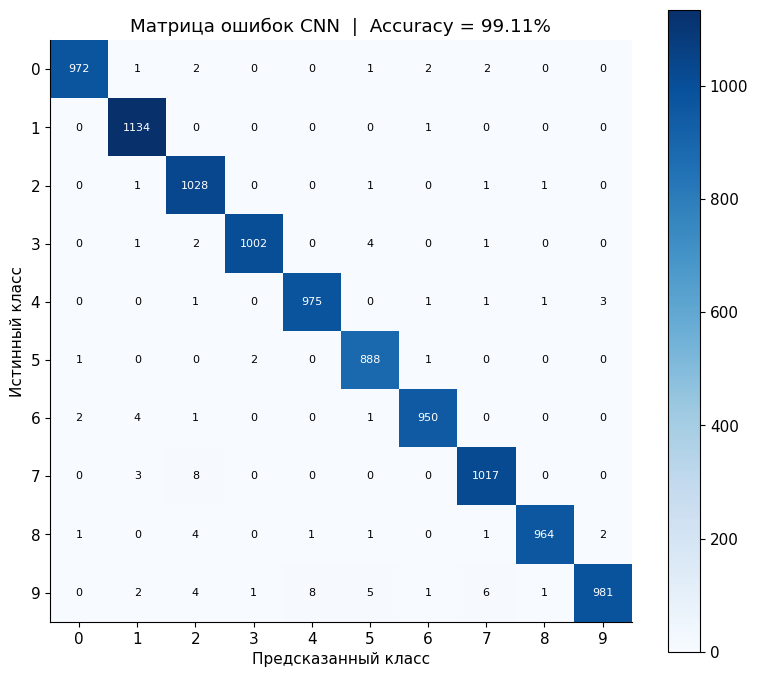

In [19]:
# =============================================================
# Визуализация: выученные ядра первого слоя + confusion matrix
# =============================================================

first_conv = cnn_model.features[0]
weights = first_conv.weight.detach().cpu().numpy()

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i in range(32):
    ax = axes[i // 8, i % 8]
    ax.imshow(weights[i, 0], cmap='RdBu_r', vmin=-weights.std()*2, vmax=weights.std()*2)
    ax.axis('off')
    ax.set_title(f'#{i}', fontsize=7)

plt.suptitle('Все 32 выученных ядра первого свёрточного слоя (3x3)\n'
             'Сравните с классическими ядрами из раздела 5 — некоторые похожи на детекторы границ',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

from sklearn.metrics import confusion_matrix

cnn_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        logits = cnn_model(x.to(device))
        all_preds.append(logits.argmax(1).cpu())
        all_labels.append(y)
all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)
for i in range(10):
    for j in range(10):
        color = 'white' if cm[i,j] > cm.max()/2 else 'black'
        ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=8, color=color)
ax.set_xlabel('Предсказанный класс'); ax.set_ylabel('Истинный класс')
ax.set_title(f'Матрица ошибок CNN  |  Accuracy = {(all_preds==all_labels).mean()*100:.2f}%')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
plt.tight_layout()
plt.show()

---

## Раздел 10: Итоговая панель

In [ ]:
# =============================================================
# Итоговая сводная панель
# =============================================================

fig = plt.figure(figsize=(22, 14))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

ax = fig.add_subplot(gs[0, 0])
ax.bar(['FC', 'CNN'], [n_params_fc, n_params_cnn], color=['tomato', 'steelblue'])
ax.set_yscale('log')
ax.set_title(f'Параметры (log scale)\nFC/CNN = {n_params_fc/n_params_cnn:.1f}x')
for i, v in enumerate([n_params_fc, n_params_cnn]):
    ax.text(i, v*1.1, f'{v:,}', ha='center', fontsize=9)

ax = fig.add_subplot(gs[0, 1])
ax.plot(ep, [a*100 for a in hist_fc['val_acc']],  lw=2, color='tomato',   label='FC')
ax.plot(ep, [a*100 for a in hist_cnn['val_acc']], lw=2, color='steelblue', label='CNN')
ax.set_title('Val Accuracy по эпохам'); ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_xlabel('Эпоха')

ax = fig.add_subplot(gs[0, 2])
ax.imshow(result_manual, cmap='gray')
ax.set_title('Sobel-X (своя реализация)'); ax.axis('off')

ax = fig.add_subplot(gs[0, 3])
lap = kernels['Laplacian (all edges)']
ax.imshow(lap, cmap='RdBu_r', vmin=-3, vmax=3)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{lap[i,j]:.0f}', ha='center', va='center', fontsize=10)
ax.set_title('Пример классического ядра\n(Laplacian)'); ax.set_xticks([]); ax.set_yticks([])

ax = fig.add_subplot(gs[1, 0])
out_demo = F.conv2d(img_batch, kernel_demo, padding=1, stride=2)
ax.imshow(out_demo.squeeze().numpy(), cmap='gray')
ax.set_title('padding=1, stride=2\n(downsampling)'); ax.axis('off')

ax = fig.add_subplot(gs[1, 1])
ax.imshow(maxp, cmap='gray')
ax.set_title('MaxPool 4x4'); ax.axis('off')

ax = fig.add_subplot(gs[1, 2])
ax.imshow(feat_maps[0].squeeze(0)[0].cpu().numpy(), cmap='viridis')
ax.set_title('Feature map (слой 1)'); ax.axis('off')

ax = fig.add_subplot(gs[1, 3])
grid_kernels = np.zeros((4*3, 8*3))
for i in range(32):
    r, c = i // 8, i % 8
    grid_kernels[r*3:(r+1)*3, c*3:(c+1)*3] = weights[i, 0]
ax.imshow(grid_kernels, cmap='RdBu_r', vmin=-weights.std()*2, vmax=weights.std()*2)
ax.set_title('Все 32 выученных ядра\n(первый слой CNN)'); ax.axis('off')

ax = fig.add_subplot(gs[2, 0])
fc_confs  = [c for _, c in confidences]
cnn_confs = [c for _, c in confidences_cnn]
ax.plot(shifts, fc_confs,  marker='o', lw=2, color='tomato',   label='FC')
ax.plot(shifts, cnn_confs, marker='o', lw=2, color='steelblue', label='CNN')
ax.set_xlabel('Сдвиг, px'); ax.set_ylabel('Confidence')
ax.set_title('Устойчивость к сдвигу'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = fig.add_subplot(gs[2, 1])
im = ax.imshow(cm, cmap='Blues')
ax.set_title(f'Confusion Matrix CNN\nAcc={(all_preds==all_labels).mean()*100:.1f}%')
ax.set_xticks([]); ax.set_yticks([])

ax = fig.add_subplot(gs[2, 2])
ax.plot(ep, hist_fc['val_loss'],  lw=2, color='tomato',   label='FC')
ax.plot(ep, hist_cnn['val_loss'], lw=2, color='steelblue', label='CNN')
ax.set_title('Val Loss'); ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_xlabel('Эпоха')

ax = fig.add_subplot(gs[2, 3])
ax.axis('off')
summary_data = [
    ['Метрика', 'FC', 'CNN'],
    ['Параметры', f'{n_params_fc:,}', f'{n_params_cnn:,}'],
    ['Val Accuracy', f'{hist_fc["val_acc"][-1]*100:.1f}%', f'{hist_cnn["val_acc"][-1]*100:.1f}%'],
    ['Conf. при сдвиге 10px', f'{fc_confs[-1]:.2f}', f'{cnn_confs[-1]:.2f}'],
]
t = ax.table(cellText=summary_data[1:], colLabels=summary_data[0],
              cellLoc='center', loc='center', bbox=[0,0,1,1])
t.auto_set_font_size(False); t.set_fontsize(9)
for (r,c), cell in t.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50'); cell.set_text_props(color='white', weight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#ecf0f1')

fig.suptitle('Полносвязные сети, свёртки и CNN — итоговая панель', fontsize=16, fontweight='bold')
plt.savefig('cnn_final_panel.png', dpi=100, bbox_inches='tight')
plt.show()

print('Занятие завершено.')

In [ ]:
# =============================================================
# Сохранение моделей
# =============================================================

torch.save({
    'fc_model':  fc_model.state_dict(),
    'cnn_model': cnn_model.state_dict(),
}, 'cnn_vs_fc_models.pt')

print('Модели сохранены в cnn_vs_fc_models.pt')
print('''
Загрузка:
    ckpt = torch.load('cnn_vs_fc_models.pt')

    fc = FullyConnectedNet(num_classes=10)
    fc.load_state_dict(ckpt['fc_model'])

    cnn = SimpleCNN(num_classes=10)
    cnn.load_state_dict(ckpt['cnn_model'])
''')

---

## Итоги занятия

### Что мы разобрали

| Тема | Ключевая идея |
|------|---------------|
| Полносвязные сети | Каждый нейрон связан со всеми входами — много параметров, нет учёта структуры |
| Проблемы FC для изображений | Взрывной рост параметров, нет пространственной структуры, нет translation invariance |
| Свёртка | Local connectivity + parameter sharing — решает все три проблемы |
| Классические ядра | Sobel, Laplacian, Gaussian blur — вручную спроектированные детекторы признаков |
| Padding/Stride/Pooling | Контроль пространственного размера feature maps |
| CNN-классификатор | Иерархия признаков: от границ (ранние слои) к абстрактным паттернам (глубокие слои) |
| BatchNorm | Стабилизирует обучение, нормализуя активации |
| Global Average Pooling | Компактная альтернатива Flatten перед классификатором |

### Главный вывод

CNN при значительно меньшем числе параметров достигает того же или лучшего качества, чем полносвязная сеть, и при этом гораздо устойчивее к сдвигам объекта — это прямое следствие parameter sharing и local connectivity, заложенных в саму операцию свёртки.

---

## Вопросы для обсуждения

1. Посчитайте вручную число параметров для Conv2d(in_channels=3, out_channels=64, kernel_size=3) и для Linear слоя, принимающего на вход развёрнутое изображение 64x64x3 и выдающего 64 выхода. Сравните порядки величин.

2. Почему BatchNorm обычно ставится после Conv, но до активации (ReLU)? Что изменится, если поменять порядок?

3. Объясните, почему MaxPooling даёт частичную инвариантность к сдвигу, а Flatten + Linear — нет.

4. Если увеличить kernel_size с 3x3 до 7x7, как это повлияет на: (а) число параметров слоя, (б) рецептивное поле, (в) вычислительную стоимость?

5. Мы увидели, что CNN устойчивее к сдвигу, чем FC, но не идеально инвариантна. Почему?

---

## Домашнее задание

**Уровень 1.** Замените MaxPool на AvgPool во всех блоках CNN. Сравните итоговую точность и кривые обучения с оригинальной версией.

**Уровень 2.** Добавьте Dropout(0.3) перед классификатором в CNN и в FC-сеть. Сравните, насколько это меняет разрыв между train и val accuracy (переобучение) для каждой архитектуры.

**Уровень 3.** Реализуйте conv2d_manual для случая нескольких входных каналов (in_channels > 1) и нескольких выходных фильтров одновременно (out_channels > 1), без использования циклов Python там, где это можно векторизовать через np.einsum или as_strided. Сравните скорость со своей наивной версией и с torch.nn.functional.conv2d.

---

## Ключевые работы

- LeCun et al. (1998) — LeNet, первая успешная CNN, рукописные цифры
- Krizhevsky et al. (2012) — AlexNet, прорыв deep learning в компьютерном зрении
- Simonyan & Zisserman (2014) — VGG, глубина через стек 3x3 свёрток
- Ioffe & Szegedy (2015) — Batch Normalization
- He et al. (2015) — ResNet, skip connections для очень глубоких сетей
- Lin et al. (2013) — Network in Network, идея Global Average Pooling